In [2]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd 


In [19]:
import pandas as pd

path = "/mnt/c/Users/fss6k/OneDrive - University of Glasgow/Desktop/GALLANT_WS3_documents_data/Data Zones 2022/Data Zones 2022/simd2020_withinds.csv"
df = pd.read_csv(path)
df.rename(columns={'Data_Zone':'DataZone'}, inplace=True)
df.head()
# df.describe(include='all')
print(df.columns)


Index(['DataZone', 'Intermediate_Zone', 'Council_area', 'Total_population',
       'Working_Age_population', 'SIMD2020v2_Rank', 'SIMD_2020v2_Percentile',
       'SIMD2020v2_Vigintile', 'SIMD2020v2_Decile', 'SIMD2020v2_Quintile',
       'SIMD2020v2_Income_Domain_Rank', 'SIMD2020_Employment_Domain_Rank',
       'SIMD2020_Health_Domain_Rank', 'SIMD2020_Education_Domain_Rank',
       'SIMD2020_Access_Domain_Rank', 'SIMD2020_Crime_Domain_Rank',
       'SIMD2020_Housing_Domain_Rank', 'income_rate', 'income_count',
       'employment_rate', 'employment_count', 'CIF', 'ALCOHOL', 'DRUG', 'SMR',
       'DEPRESS', 'LBWT', 'EMERG', 'Attendance', 'Attainment',
       'no_qualifications', 'not_participating', 'University', 'crime_count',
       'crime_rate', 'overcrowded_count', 'nocentralheating_count',
       'overcrowded_rate', 'nocentralheating_rate', 'drive_petrol', 'drive_GP',
       'drive_post', 'drive_primary', 'drive_retail', 'drive_secondary',
       'PT_GP', 'PT_post', 'PT_retail', 'broa

In [10]:
import geopandas as gpd
path = "/mnt/c/Users/fss6k/OneDrive - University of Glasgow/Desktop/GALLANT_WS3_documents_data/Data Zones 2022/Data Zones 2022/sc_dz_11.shp"
gdf = gpd.read_file(path)

gdf.head()


,DataZone,Name,TotPop2011,ResPop2011,HHCnt2011,StdAreaHa,StdAreaKm2,Shape_Leng,Shape_Area,geometry
0,S01006506,Culter - 01,872,852,424,438.880218,4.388801,11801.872345,4.388802e+06,"POLYGON ((-2.27748 57.09527, -2.27644 57.09521..."
1,S01006507,Culter - 02,836,836,364,22.349739,0.223498,2900.406362,2.217468e+05,"POLYGON ((-2.27354 57.10449, -2.27333 57.10449..."
2,S01006508,Culter - 03,643,643,340,27.019476,0.270194,3468.761949,2.701948e+05,"POLYGON ((-2.27443 57.10171, -2.27237 57.10046..."
3,S01006509,Culter - 04,580,580,274,9.625426,0.096254,1647.461389,9.625426e+04,"POLYGON ((-2.26611 57.10133, -2.26599 57.10092..."
4,S01006510,Culter - 05,644,577,256,18.007657,0.180076,3026.111412,1.800766e+05,"POLYGON ((-2.26013 57.1016, -2.2605 57.10134, ..."


<Axes: >

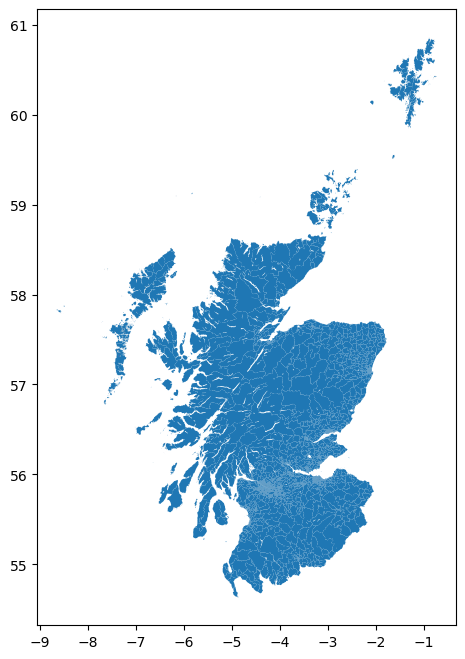

In [11]:
gdf.plot(figsize=(8, 8))


In [17]:
# Merge CSV data into the GeoDataFrame
merged = gdf.merge(df, on='DataZone', how='left')

100%|██████████| 6/6 [00:14<00:00,  2.50s/it]


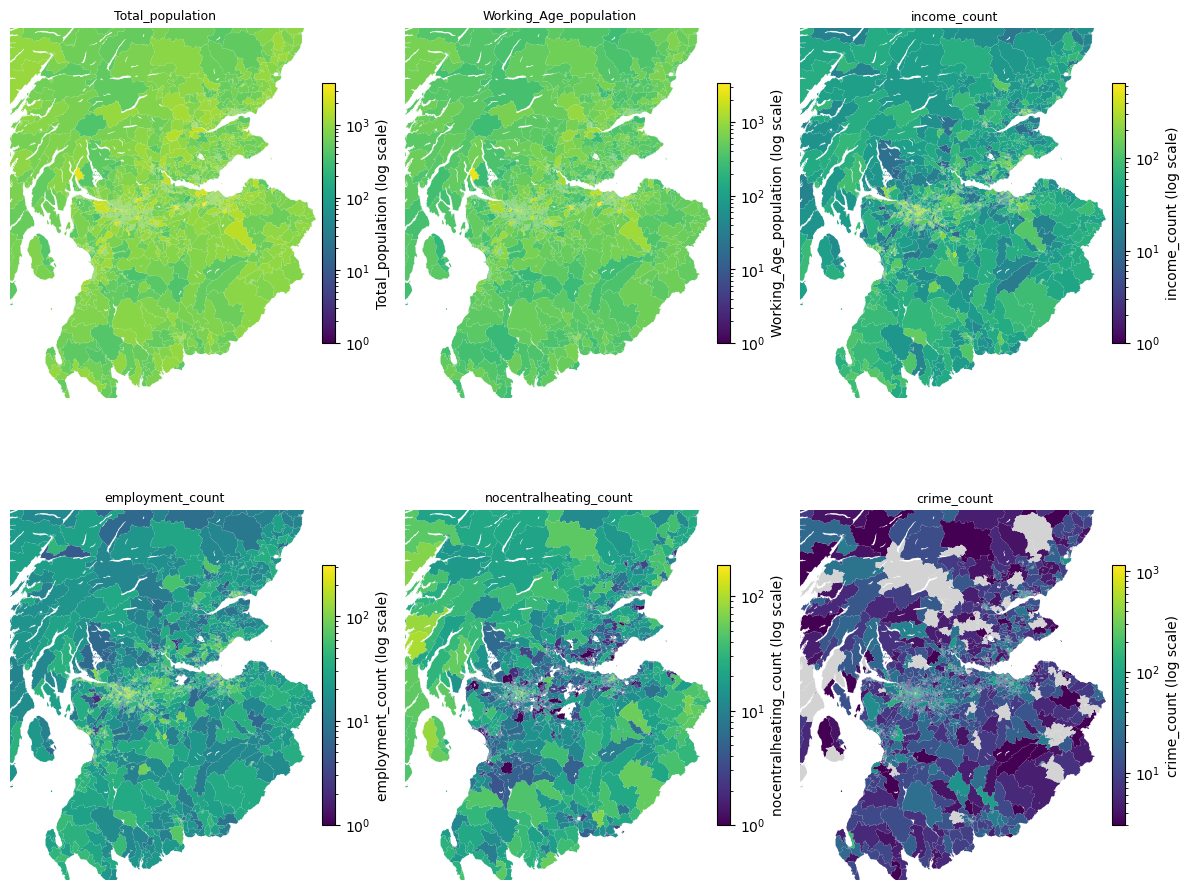

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from pandas.api.types import is_numeric_dtype
from matplotlib.colors import LogNorm
from matplotlib.cm import ScalarMappable

# your columns
cols = [
    'Total_population',
    'Working_Age_population',
    'income_count',
    'employment_count',
    'nocentralheating_count',
    'crime_count'
]

# 1) coerce to numeric (safe even if already numeric)
for c in cols:
    if c in merged.columns and not is_numeric_dtype(merged[c]):
        merged[c] = pd.to_numeric(merged[c], errors='coerce')

# 2) subplots
n = len(cols)
ncols = 3
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 10))
axes = axes.flatten()

xmin, xmax = -5.6, -2.0
ymin, ymax = 54.7, 57.0


for i, col in tqdm(list(enumerate(cols)), total=len(cols)):
    ax = axes[i]

    # avoid zero or negative values (not allowed in log)
    data = merged[col].clip(lower=1e0)

    vmin = data.min()
    vmax = data.max()

    norm = LogNorm(vmin=vmin, vmax=vmax)
    cmap = 'viridis'

    merged.plot(
        column=col,
        ax=ax,
        cmap=cmap,
        norm=norm,
        legend=False,
        missing_kwds={"color": "lightgrey", "label": "Missing"}
    )

    # add log-scaled colorbar
    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, orientation='vertical', fraction=0.04, pad=0.01)
    cbar.set_label(f"{col} (log scale)")

    ax.set_title(col, fontsize=9)
    ax.axis('off')
    # Zoom limits (focus between Glasgow and Edinburgh)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

# hide any unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()



In [ ]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd 


In [46]:
merged.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich